<a href="https://colab.research.google.com/github/loser-2-o/CVD/blob/main/CVD_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cardiovascular Disease Prediction Using Explainable Ensemble Learning An Interpretable Ensemble Approach with SHAP and LIME

---
**Dataset:** fedesoriano Heart Failure Prediction (918 records, 11 features)

In [18]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


## 1. Install & Import Libraries

In [19]:
!pip install shap lime imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy.stats import kendalltau

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset

In [20]:
df = pd.read_csv('heart.csv')
print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset loaded!
Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Exploratory Data Analysis (EDA)

📊 Class Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

CVD: 508 | No CVD: 410


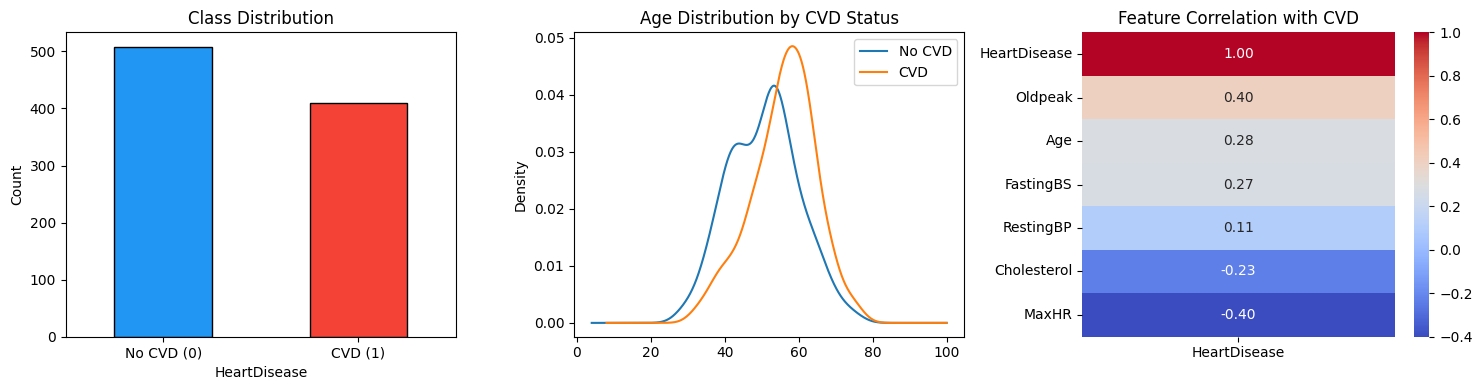

✅ EDA complete!


In [21]:
print("📊 Class Distribution:")
print(df['HeartDisease'].value_counts())
print(f"\nCVD: {df['HeartDisease'].sum()} | No CVD: {(df['HeartDisease']==0).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
df['HeartDisease'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2196F3','#F44336'], edgecolor='black'
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No CVD (0)', 'CVD (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Age distribution
df.groupby('HeartDisease')['Age'].plot(kind='kde', ax=axes[1])
axes[1].set_title('Age Distribution by CVD Status')
axes[1].legend(['No CVD', 'CVD'])

# Correlation heatmap
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr[['HeartDisease']].sort_values('HeartDisease', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2])
axes[2].set_title('Feature Correlation with CVD')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150)
plt.show()
print("✅ EDA complete!")

## 4. Data Preprocessing

In [22]:
# Cholesterol zero fix
df['Cholesterol'] = df['Cholesterol'].replace(
    0, df[df['Cholesterol'] > 0]['Cholesterol'].median()
)

# Label encoding
le = LabelEncoder()
for col in ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
feature_names = X.columns.tolist()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Preprocessing done!")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nFeatures ({len(feature_names)}):")
for i, f in enumerate(feature_names, 1):
    print(f"  {i}. {f}")

✅ Preprocessing done!
Train: 734 | Test: 184

Features (11):
  1. Age
  2. Sex
  3. ChestPainType
  4. RestingBP
  5. Cholesterol
  6. FastingBS
  7. RestingECG
  8. MaxHR
  9. ExerciseAngina
  10. Oldpeak
  11. ST_Slope


## 5. Base Paper A — Ensemble + SHAP
*(Nature Scientific Reports, 2025 — Ganie et al.)*

**What they did:** Multiple base models → Stacking + Voting Ensemble → SHAP
**We implement:** Same approach on fedesoriano dataset (918 patients)

    BASE PAPER A — RESULTS

🔹 Voting Ensemble:
   Accuracy: 86.96
   Precision: 89.0
   Recall: 87.25
   F1-Score: 0.8812
   ROC-AUC: 0.9277

🔹 Stacking Ensemble:
   Accuracy: 86.96
   Precision: 88.24
   Recall: 88.24
   F1-Score: 0.8824
   ROC-AUC: 0.9249

⏳ SHAP analysis is currently running...


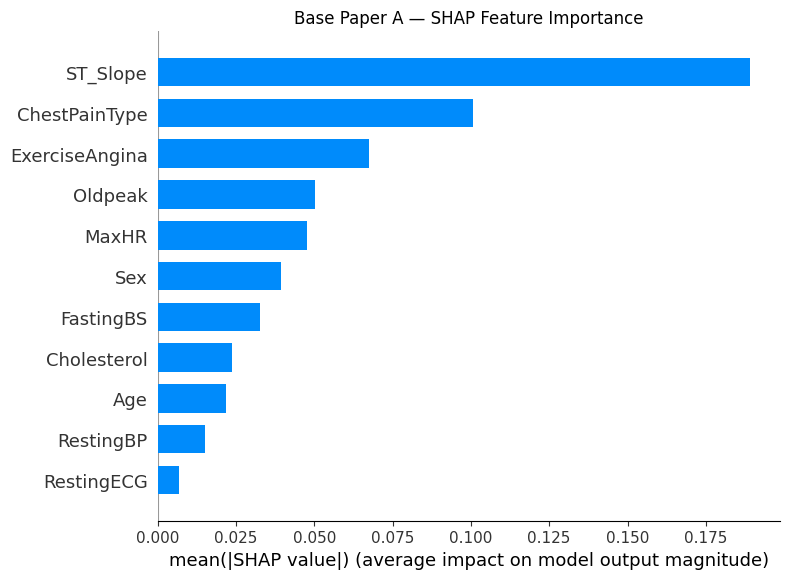


📊 SHAP Feature Ranking (Base Paper A):
       Feature  SHAP_Score  Rank_SHAP_A
      ST_Slope    0.189218            1
 ChestPainType    0.100761            2
ExerciseAngina    0.067606            3
       Oldpeak    0.050114            4
         MaxHR    0.047612            5
           Sex    0.039527            6
     FastingBS    0.032592            7
   Cholesterol    0.023808            8
           Age    0.021702            9
     RestingBP    0.015030           10
    RestingECG    0.006918           11

✅ Base Paper A Complete!


In [23]:
# ── BASE MODELS ───────────────────────────────
lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
gb  = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
svm = SVC(probability=True, random_state=42)

# ── VOTING ENSEMBLE ───────────────────────────
voting_A = VotingClassifier(
    estimators=[('lr',lr),('rf',rf),('gb',gb),('xgb',xgb),('svm',svm)],
    voting='soft'
)
voting_A.fit(X_train, y_train)

# ── STACKING ENSEMBLE ─────────────────────────
stacking_A = StackingClassifier(
    estimators=[('rf',RandomForestClassifier(n_estimators=100, random_state=42)),
                ('gb',GradientBoostingClassifier(n_estimators=100, random_state=42)),
                ('xgb',XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_A.fit(X_train, y_train)

# ── RESULTS ───────────────────────────────────
print("="*50)
print("    BASE PAPER A — RESULTS")
print("="*50)

results_A = {}
for name, model in [("Voting", voting_A), ("Stacking", stacking_A)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results_A[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred)*100, 2),
        'Precision': round(precision_score(y_test, y_pred)*100, 2),
        'Recall': round(recall_score(y_test, y_pred)*100, 2),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f"\n🔹 {name} Ensemble:")
    for k,v in results_A[name].items():
        print(f"   {k}: {v}")

# ── SHAP ──────────────────────────────────────
print("\n⏳ SHAP analysis is currently running...")

rf_A = RandomForestClassifier(n_estimators=100, random_state=42)
rf_A.fit(X_train, y_train)

explainer_A = shap.TreeExplainer(rf_A)
shap_values_A = explainer_A.shap_values(X_test)

# Handle the new SHAP version
if isinstance(shap_values_A, list):
    sv_A = shap_values_A[1]
elif len(shap_values_A.shape) == 3:
    sv_A = shap_values_A[:, :, 1]
else:
    sv_A = shap_values_A

# SHAP Summary Plot
plt.figure(figsize=(10,6))
shap.summary_plot(sv_A, X_test,
                  feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Base Paper A — SHAP Feature Importance")
plt.tight_layout()
plt.savefig('basepaper_A_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP Ranking
shap_rank_A = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Score': np.abs(sv_A).mean(axis=0)
}).sort_values('SHAP_Score', ascending=False).reset_index(drop=True)
shap_rank_A['Rank_SHAP_A'] = range(1, len(shap_rank_A)+1)

print("\n📊 SHAP Feature Ranking (Base Paper A):")
print(shap_rank_A[['Feature','SHAP_Score','Rank_SHAP_A']].to_string(index=False))
print("\n✅ Base Paper A Complete!")

## 6. Base Paper B — Ensemble + SHAP + LIME
*(Frontiers, 2025)*

**What they did:** EBM + XGBoost soft voting → SHAP + LIME both used → Kendall's τ for fold-to-fold stability

**We implement:** Ensemble + SHAP + LIME on fedesoriano dataset (918 patients)

    BASE PAPER B — RESULTS

🔹 GB+XGBoost Voting Ensemble:
   Accuracy: 87.5
   Precision: 89.9
   Recall: 87.25
   F1-Score: 0.8856
   ROC-AUC: 0.9206

⏳ SHAP analysis is currently running...


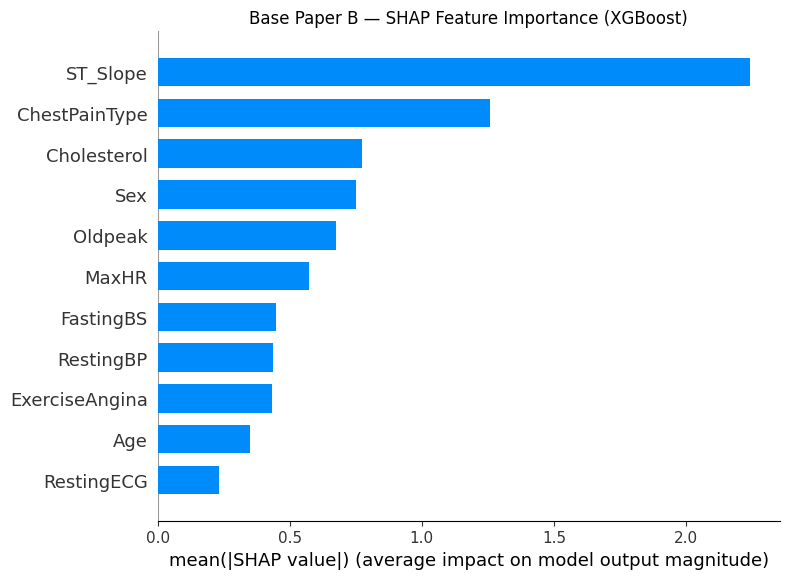


📊 SHAP Feature Ranking (Base Paper B):
       Feature  SHAP_Score  Rank_SHAP_B
      ST_Slope    2.243466            1
 ChestPainType    1.257070            2
   Cholesterol    0.774773            3
           Sex    0.751077            4
       Oldpeak    0.675362            5
         MaxHR    0.573350            6
     FastingBS    0.448527            7
     RestingBP    0.435241            8
ExerciseAngina    0.434582            9
           Age    0.350031           10
    RestingECG    0.234247           11

⏳ LIME analysis is running..

📊 SHAP vs LIME Ranking Comparison (Base Paper B):
       Feature  Rank_SHAP_B  Rank_LIME_B
      ST_Slope            1            8
 ChestPainType            2           11
   Cholesterol            3            3
           Sex            4           10
       Oldpeak            5            7
         MaxHR            6            2
     FastingBS            7            9
     RestingBP            8            6
ExerciseAngina            9   

In [24]:
# ── ENSEMBLE (GB + XGBoost soft voting) ───────
gb_B  = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgb_B = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

voting_B = VotingClassifier(
    estimators=[('gb', gb_B), ('xgb', xgb_B)],
    voting='soft'
)
voting_B.fit(X_train, y_train)

# ── RESULTS ───────────────────────────────────
print("="*50)
print("    BASE PAPER B — RESULTS")
print("="*50)

y_pred_B = voting_B.predict(X_test)
y_prob_B = voting_B.predict_proba(X_test)[:,1]

results_B = {
    'Accuracy': round(accuracy_score(y_test, y_pred_B)*100, 2),
    'Precision': round(precision_score(y_test, y_pred_B)*100, 2),
    'Recall': round(recall_score(y_test, y_pred_B)*100, 2),
    'F1-Score': round(f1_score(y_test, y_pred_B), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_B), 4)
}
print("\n🔹 GB+XGBoost Voting Ensemble:")
for k, v in results_B.items():
    print(f"   {k}: {v}")

# ── SHAP ──────────────────────────────────────
print("\n⏳ SHAP analysis is currently running...")

xgb_B_fit = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_B_fit.fit(X_train, y_train)

explainer_B = shap.TreeExplainer(xgb_B_fit)
shap_values_B = explainer_B.shap_values(X_test)

if isinstance(shap_values_B, list):
    sv_B = shap_values_B[1]
elif len(shap_values_B.shape) == 3:
    sv_B = shap_values_B[:, :, 1]
else:
    sv_B = shap_values_B

plt.figure(figsize=(10,6))
shap.summary_plot(sv_B, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Base Paper B — SHAP Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig('basepaper_B_shap.png', dpi=150, bbox_inches='tight')
plt.show()

shap_rank_B = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Score': np.abs(sv_B).mean(axis=0)
}).sort_values('SHAP_Score', ascending=False).reset_index(drop=True)
shap_rank_B['Rank_SHAP_B'] = range(1, len(shap_rank_B)+1)

print("\n📊 SHAP Feature Ranking (Base Paper B):")
print(shap_rank_B[['Feature','SHAP_Score','Rank_SHAP_B']].to_string(index=False))

# ── LIME ──────────────────────────────────────
print("\n⏳ LIME analysis is running..")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['No CVD', 'CVD'],
    mode='classification',
    random_state=42
)

# Compute the LIME feature importance for each test sample and then average the results
lime_importance = np.zeros(len(feature_names))
n_samples_lime = 50  # For faster execution, only the first 50 test samples are being used
for i in range(n_samples_lime):
    exp = lime_explainer.explain_instance(
        X_test[i],
        xgb_B_fit.predict_proba,
        num_features=len(feature_names)
    )
    for feat_idx, weight in exp.local_exp[1]:
        lime_importance[feat_idx] += abs(weight)

lime_importance /= n_samples_lime

shap_rank_B['LIME_Score'] = lime_importance
shap_rank_B['Rank_LIME_B'] = shap_rank_B['LIME_Score'].rank(ascending=False).astype(int)

print("\n📊 SHAP vs LIME Ranking Comparison (Base Paper B):")
print(shap_rank_B[['Feature','Rank_SHAP_B','Rank_LIME_B']].sort_values('Rank_SHAP_B').to_string(index=False))

# ── Kendall's tau (Frontiers paper style) ──
tau, p_value = kendalltau(shap_rank_B['Rank_SHAP_B'], shap_rank_B['Rank_LIME_B'])
print(f"\n📈 Kendall's τ (SHAP vs LIME ranking correlation): {tau:.4f}")
print(f"   p-value: {p_value:.4f}")

print("\n✅ Base Paper B Complete!")

## 7. My Proposed Work — SMOTE + Ensemble + SHAP vs LIME Agreement Analysis
**(Novelty)**

**Contribution:**
- Leakage-free SMOTE (applied only inside each CV training fold)
- 5-Fold Cross Validation with Voting Ensemble (LR+RF+GB+XGB+SVM)
- SHAP vs LIME agreement measured via Kendall's τ — per fold, reported as mean ± SD
- Disagreement analysis — checking whether SHAP-LIME mismatches cluster around borderline predictions

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import wilcoxon, pointbiserialr, binomtest

# >>> ADDED: load raw (unencoded) dataframe once, for human-readable subgroup labels
df_raw = pd.read_csv('heart.csv')
def make_age_group(age):
    if age < 45:
        return '<45'
    elif age <= 60:
        return '45-60'
    else:
        return '60+'
df_raw['AgeGroup'] = df_raw['Age'].apply(make_age_group)
performance_records = []   # >>> ADDED: one row per test-fold instance, every fold
agreement_records = []     # >>> ADDED: one row per SHAP/LIME-explained instance only

# ══════════════════════════════════════════════
# NESTED LEAKAGE-FREE 5-FOLD CV
# Hyperparameter tuning now runs INSIDE each outer fold, using ONLY that
# fold's training data — before SMOTE (to avoid synthetic-sample leakage
# into the inner tuning CV as well). This replaces the earlier design where
# tuning ran once on the full dataset before the outer split.
# ══════════════════════════════════════════════
X_raw = X.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
fold_results_single = []
fold_tau = []
disagreement_records = []
fold_best_params = []   # >>> ADDED: record each fold's own tuned hyperparameters

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

fold_num = 1
for train_idx, test_idx in skf.split(X_raw, y):
    X_tr_raw, X_te_raw = X_raw[train_idx], X_raw[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # ✅ Scaling was fitted only on the training fold
    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X_tr_raw)
    X_te = fold_scaler.transform(X_te_raw)

    # ══════════════════════════════════════════
    # ✅NESTED HYPERPARAMETER TUNING — Performed only on the training data of the current fold,
    # before applying SMOTE (i.e., on the original class-imbalanced data), using
    # ROC-AUC as the scoring metric because it is robust to class imbalance.
    # ══════════════════════════════════════════
    print(f"⏳ Fold {fold_num}: nested hyperparameter tuning is running...")

    xgb_search = RandomizedSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss'),
        xgb_param_grid, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
    )
    xgb_search.fit(X_tr, y_tr)
    best_xgb_params = xgb_search.best_params_

    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42),
        rf_param_grid, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
    )
    rf_search.fit(X_tr, y_tr)
    best_rf_params = rf_search.best_params_

    fold_best_params.append({'Fold': fold_num, 'XGB_params': best_xgb_params, 'RF_params': best_rf_params})
    print(f"   ✅ Fold {fold_num} tuned XGBoost: {best_xgb_params}")
    print(f"   ✅ Fold {fold_num} tuned RF:      {best_rf_params}")

    # ✅ # SMOTE — applied only to the training fold after hyperparameter tuning.
    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    # # Voting Ensemble — using the tuned XGBoost and tuned RF models specific to this fold.
    voting_p = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(**best_rf_params, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')),
            ('svm', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    )
    voting_p.fit(X_tr_sm, y_tr_sm)

    y_pred = voting_p.predict(X_te)
    y_prob = voting_p.predict_proba(X_te)[:,1]

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    fold_results.append({'Fold': fold_num, 'Accuracy': acc*100, 'F1': f1, 'AUC': auc})

    # >>> ADDED: log per-instance performance for this fold, tagged with Sex/AgeGroup/ChestPainType
    perf_sub = df_raw.iloc[test_idx][['Sex', 'AgeGroup', 'ChestPainType']].copy()
    perf_sub['fold'] = fold_num
    perf_sub['y_true'] = y_te.values
    perf_sub['y_pred'] = y_pred
    perf_sub['y_prob'] = y_prob
    performance_records.append(perf_sub)

    # Single best model (this fold's own tuned XGBoost alone) — statistical test-এর জন্য
    xgb_single = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')
    xgb_single.fit(X_tr_sm, y_tr_sm)
    y_pred_single = xgb_single.predict(X_te)
    acc_single = accuracy_score(y_te, y_pred_single)
    fold_results_single.append({'Fold': fold_num, 'Accuracy': acc_single*100})

    # SHAP (this fold's own tuned RF)
    rf_fold = RandomForestClassifier(**best_rf_params, random_state=42)
    rf_fold.fit(X_tr_sm, y_tr_sm)
    explainer_fold = shap.TreeExplainer(rf_fold)
    shap_vals_fold = explainer_fold.shap_values(X_te)
    if isinstance(shap_vals_fold, list):
        sv_fold = shap_vals_fold[1]
    elif len(shap_vals_fold.shape) == 3:
        sv_fold = shap_vals_fold[:, :, 1]
    else:
        sv_fold = shap_vals_fold

    shap_imp_fold = np.abs(sv_fold).mean(axis=0)
    shap_rank_fold = pd.Series(shap_imp_fold, index=feature_names).rank(ascending=False)

    # ✅ # TARGETED LIME SAMPLING — all borderline cases plus 100 randomly selected additional samples.
    dist_from_boundary = np.abs(y_prob - 0.5)
    borderline_idx = np.where(dist_from_boundary <= 0.15)[0]
    other_idx = np.where(dist_from_boundary > 0.15)[0]
    np.random.seed(42)
    other_sample_idx = np.random.choice(other_idx, size=min(100, len(other_idx)), replace=False)
    lime_sample_idx = np.concatenate([borderline_idx, other_sample_idx])
    n_lime = len(lime_sample_idx)

    lime_exp_fold = lime.lime_tabular.LimeTabularExplainer(
        X_tr_sm, feature_names=feature_names, class_names=['No CVD','CVD'],
        mode='classification', random_state=42
    )

    lime_imp_fold = np.zeros(len(feature_names))

    for i in lime_sample_idx:
        exp = lime_exp_fold.explain_instance(X_te[i], rf_fold.predict_proba, num_features=len(feature_names))
        local_imp = np.zeros(len(feature_names))
        for feat_idx, weight in exp.local_exp[1]:
            local_imp[feat_idx] = abs(weight)
        lime_imp_fold += local_imp

        top_shap_feat = feature_names[np.argmax(np.abs(sv_fold[i]))]
        top_lime_feat = feature_names[np.argmax(local_imp)]
        agree_flag = (top_shap_feat == top_lime_feat)

        disagreement_records.append({
            'Fold': fold_num,
            'Predicted_Prob': y_prob[i],
            'True_Label': y_te.iloc[i],
            'Top_SHAP_Feature': top_shap_feat,
            'Top_LIME_Feature': top_lime_feat,
            'Agree': agree_flag
        })

        # >>> ADDED: log this explained instance's subgroup + agreement flag
        original_idx = test_idx[i]   # map back to df_raw's row position
        agr_row = df_raw.iloc[[original_idx]][['Sex', 'AgeGroup', 'ChestPainType']].copy()
        agr_row['fold'] = fold_num
        agr_row['agree'] = int(agree_flag)
        agreement_records.append(agr_row)

    lime_imp_fold /= n_lime
    lime_rank_fold = pd.Series(lime_imp_fold, index=feature_names).rank(ascending=False)

    tau_fold, p_fold = kendalltau(shap_rank_fold, lime_rank_fold)
    fold_tau.append({'Fold': fold_num, 'Kendall_tau': tau_fold, 'p_value': p_fold})

    print(f"✅ Fold {fold_num} — Ensemble: {acc*100:.2f}% | Single-XGB: {acc_single*100:.2f}% | τ: {tau_fold:.4f} | LIME samples: {n_lime} (borderline: {len(borderline_idx)})\n")
    fold_num += 1

print("\n" + "="*50)
print("   NESTED TUNING — HYPERPARAMETERS SELECTED PER FOLD")
print("="*50)
fold_params_df = pd.DataFrame(fold_best_params)
print(fold_params_df.to_string(index=False))

print("\n" + "="*50)
print("   PROPOSED WORK (LEAKAGE-FREE + NESTED-TUNED) — RESULTS")
print("="*50)

results_df = pd.DataFrame(fold_results)
print("\n📊 Per-Fold Performance (Ensemble):")
print(results_df.to_string(index=False))
print(f"\nMean Accuracy: {results_df['Accuracy'].mean():.2f}% ± {results_df['Accuracy'].std():.2f}")
print(f"Mean F1-Score: {results_df['F1'].mean():.4f} ± {results_df['F1'].std():.4f}")
print(f"Mean ROC-AUC : {results_df['AUC'].mean():.4f} ± {results_df['AUC'].std():.4f}")

tau_df = pd.DataFrame(fold_tau)
print("\n📈 SHAP vs LIME Agreement (Kendall's τ) per Fold:")
print(tau_df.to_string(index=False))
print(f"\nMean Kendall's τ: {tau_df['Kendall_tau'].mean():.4f} ± {tau_df['Kendall_tau'].std():.4f}")

# ══════════════════════════════════════════════
# STEP 3: STATISTICAL SIGNIFICANCE TEST
# ══════════════════════════════════════════════
results_single_df = pd.DataFrame(fold_results_single)
print("\n" + "="*50)
print("   STATISTICAL TEST — Ensemble vs Single Best Model (XGBoost)")
print("="*50)
print(f"\nEnsemble fold accuracies : {results_df['Accuracy'].round(2).tolist()}")
print(f"Single XGB fold accuracies: {results_single_df['Accuracy'].round(2).tolist()}")

stat, p_val = wilcoxon(results_df['Accuracy'], results_single_df['Accuracy'])
print(f"\nWilcoxon signed-rank test: statistic={stat:.4f}, p-value={p_val:.4f}")
if p_val < 0.05:
    print("✅ Statistically significant (p < 0.05) — Ensemble genuinely outperforms single model.")
else:
    print("⚠️ Not statistically significant (p ≥ 0.05) — report this honestly; with only 5 folds the test has low power.")

# ══════════════════════════════════════════════
# >>> ADDED — STEP 4: SUBGROUP ANALYSIS SUMMARY
# ══════════════════════════════════════════════
print("\n" + "="*50)
print("   SUBGROUP ANALYSIS — Sex / AgeGroup / ChestPainType")
print("="*50)

from sklearn.metrics import precision_score, recall_score
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

perf_all = pd.concat(performance_records, ignore_index=True)
agr_all = pd.concat(agreement_records, ignore_index=True)

perf_rows = []
for group_col in ['Sex', 'AgeGroup', 'ChestPainType']:
    for level, g in perf_all.groupby(group_col):
        perf_rows.append({
            'Subgroup Type': group_col, 'Level': level, 'N': len(g),
            'Accuracy': round(accuracy_score(g['y_true'], g['y_pred']), 4),
            'Precision': round(precision_score(g['y_true'], g['y_pred'], zero_division=0), 4),
            'Recall': round(recall_score(g['y_true'], g['y_pred'], zero_division=0), 4),
            'F1': round(f1_score(g['y_true'], g['y_pred'], zero_division=0), 4),
        })
perf_table = pd.DataFrame(perf_rows)
print("\n📊 Performance by subgroup:")
print(perf_table.to_string(index=False))

agr_rows, chi2_rows = [], []
for group_col in ['Sex', 'AgeGroup', 'ChestPainType']:
    for level, g in agr_all.groupby(group_col):
        n = len(g); k = int(g['agree'].sum())
        rate = k / n if n > 0 else float('nan')
        lo, hi = proportion_confint(k, n, alpha=0.05, method='beta')
        agr_rows.append({
            'Subgroup Type': group_col, 'Level': level, 'N Explained': n,
            'Agreement (%)': round(100*rate, 2),
            '95% CI Low': round(100*lo, 2), '95% CI High': round(100*hi, 2)
        })
    contingency = pd.crosstab(agr_all[group_col], agr_all['agree'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    chi2_rows.append({'Subgroup Type': group_col, 'Chi2': round(chi2,3), 'dof': dof, 'p-value': round(p,4)})

agr_table = pd.DataFrame(agr_rows)
chi2_table = pd.DataFrame(chi2_rows)
print("\n📈 SHAP-LIME agreement by subgroup (Clopper-Pearson 95% CI):")
print(agr_table.to_string(index=False))
print("\n🔬 Chi-square test — does agreement depend on subgroup membership?")
print(chi2_table.to_string(index=False))
# ══════════════════════════════════════════════
# >>> ADDED: MULTIVARIATE CONFOUND CHECK
# Univariate chi-square tests above don't rule out confounding between
# Sex/AgeGroup/ChestPainType (e.g., maybe age distribution differs by sex).
# This logistic regression tests each variable's independent effect.
# ══════════════════════════════════════════════
import statsmodels.formula.api as smf

agr_all_lr = agr_all.copy()
agr_all_lr['agree'] = agr_all_lr['agree'].astype(int)

logit_model = smf.logit('agree ~ C(Sex) + C(AgeGroup) + C(ChestPainType)', data=agr_all_lr).fit(disp=0)
print("\n🔬 Multivariate logistic regression — agree ~ Sex + AgeGroup + ChestPainType")
print(logit_model.summary())


⏳ Fold 1: nested hyperparameter tuning is running...
   ✅ Fold 1 tuned XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
   ✅ Fold 1 tuned RF:      {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 30}
✅ Fold 1 — Ensemble: 90.22% | Single-XGB: 90.76% | τ: 0.2727 | LIME samples: 119 (borderline: 19)

⏳ Fold 2: nested hyperparameter tuning is running...
   ✅ Fold 2 tuned XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
   ✅ Fold 2 tuned RF:      {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}
✅ Fold 2 — Ensemble: 84.24% | Single-XGB: 84.78% | τ: 0.4182 | LIME samples: 125 (borderline: 25)

⏳ Fold 3: nested hyperparameter tuning is running...
   ✅ Fold 3 tuned XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
   ✅ Fold 3 tuned RF:      {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 30}
✅ Fold 3 — Ensemble: 84.24% | Single-XGB: 83.15% | τ:

## 7.2 Confusion Matrix and ROC Curve — Proposed Ensemble (5-Fold Aggregated)

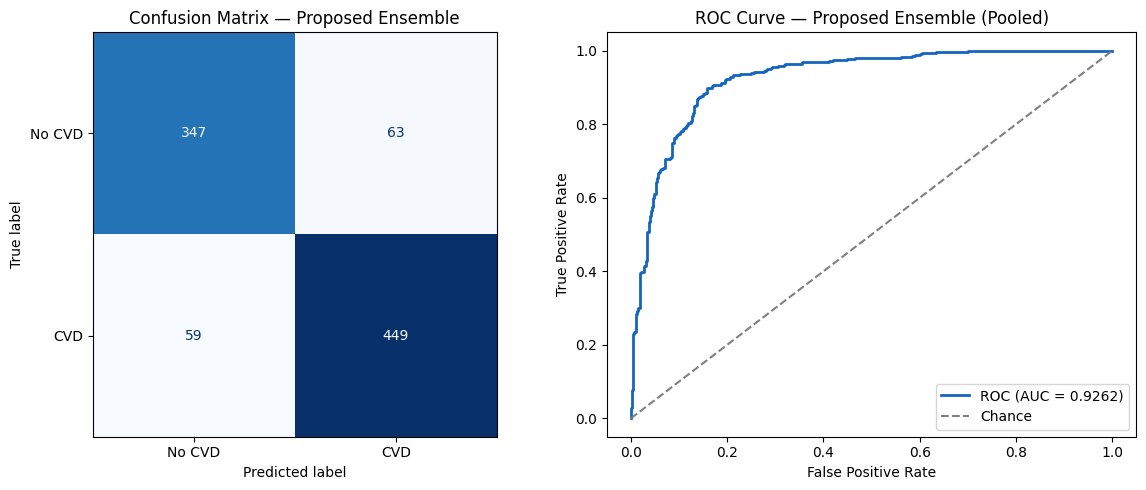

   CONFUSION MATRIX SUMMARY — PROPOSED ENSEMBLE
True Negatives:  347
False Positives: 63
False Negatives: 59
True Positives:  449

Sensitivity (Recall): 88.39%
Specificity:          84.63%
Pooled ROC-AUC:        0.9262

Note: this is a POOLED confusion matrix/ROC across all 5 test folds
(each of the 918 patients appears in exactly one fold's test set,
so this reflects leakage-free, out-of-fold predictions for the whole dataset).


In [ ]:
# ================================================
# Confusion Matrix + ROC Curve — Proposed Ensemble
# (aggregated across all 5 folds; every patient appears exactly once)
# ================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

cm = confusion_matrix(perf_all['y_true'], perf_all['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CVD', 'CVD'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix — Proposed Ensemble')

fpr, tpr, _ = roc_curve(perf_all['y_true'], perf_all['y_prob'])
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#1565C0', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Proposed Ensemble (Pooled)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print("=" * 50)
print("   CONFUSION MATRIX SUMMARY — PROPOSED ENSEMBLE")
print("=" * 50)
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nSensitivity (Recall): {tp/(tp+fn)*100:.2f}%")
print(f"Specificity:          {tn/(tn+fp)*100:.2f}%")
print(f"Pooled ROC-AUC:        {roc_auc:.4f}")
print("\nNote: this is a POOLED confusion matrix/ROC across all 5 test folds")
print("(each of the 918 patients appears in exactly one fold's test set,")
print("so this reflects leakage-free, out-of-fold predictions for the whole dataset).")


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV

print("⏳ # Fixed hyperparameter tuning — performed once and used throughout all repeated comparisons to ensure computational tractability..")

xgb_search_fixed = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
)
xgb_search_fixed.fit(X_raw, y)
fixed_xgb_params = xgb_search_fixed.best_params_

rf_search_fixed = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_search_fixed.fit(X_raw, y)
fixed_rf_params = rf_search_fixed.best_params_

print(f"   ✅ Fixed XGBoost params: {fixed_xgb_params}")
print(f"   ✅ Fixed RF params:      {fixed_rf_params}")

print("\n⏳ # Repeated 5×5 CV (25 folds) — performed for accuracy comparison only,excluding SHAP/LIME analyses to reduce computational time....")

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=7)

repeated_ensemble_acc = []
repeated_single_acc = []

fold_counter = 1
for train_idx, test_idx in rskf.split(X_raw, y):
    X_tr_raw, X_te_raw = X_raw[train_idx], X_raw[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X_tr_raw)
    X_te = fold_scaler.transform(X_te_raw)

    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    voting_r = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(**fixed_rf_params, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(**fixed_xgb_params, random_state=42, eval_metric='logloss')),
            ('svm', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    )
    voting_r.fit(X_tr_sm, y_tr_sm)
    acc_ens = accuracy_score(y_te, voting_r.predict(X_te))
    repeated_ensemble_acc.append(acc_ens*100)

    xgb_r = XGBClassifier(**fixed_xgb_params, random_state=42, eval_metric='logloss')
    xgb_r.fit(X_tr_sm, y_tr_sm)
    acc_single = accuracy_score(y_te, xgb_r.predict(X_te))
    repeated_single_acc.append(acc_single*100)

    print(f"Fold {fold_counter:2d}/25 — Ensemble: {acc_ens*100:.2f}% | Single-XGB: {acc_single*100:.2f}%")
    fold_counter += 1

print("\n" + "="*50)
print("   REPEATED 5×5 CV — 25-FOLD RESULTS")
print("="*50)
print(f"\nEnsemble   Mean Accuracy: {np.mean(repeated_ensemble_acc):.2f}% ± {np.std(repeated_ensemble_acc):.2f}")
print(f"Single-XGB Mean Accuracy: {np.mean(repeated_single_acc):.2f}% ± {np.std(repeated_single_acc):.2f}")

stat_r, p_val_r = wilcoxon(repeated_ensemble_acc, repeated_single_acc)
print(f"\nWilcoxon signed-rank test (25 pairs): statistic={stat_r:.4f}, p-value={p_val_r:.4f}")
if p_val_r < 0.05:
    print("✅ Statistically significant (p < 0.05).")
else:
    print("⚠️ Not significant (p ≥ 0.05) — both approaches perform comparably.")

n_wins_ensemble = sum(1 for e,s in zip(repeated_ensemble_acc, repeated_single_acc) if e > s)
n_wins_single = sum(1 for e,s in zip(repeated_ensemble_acc, repeated_single_acc) if s > e)
n_ties = 25 - n_wins_ensemble - n_wins_single
print(f"\n📊 Win count — Ensemble better: {n_wins_ensemble}/25 | Single better: {n_wins_single}/25 | Tie: {n_ties}/25")

from scipy import stats as sp_stats

diffs = np.array(repeated_ensemble_acc) - np.array(repeated_single_acc)
n = len(diffs)
n_splits_used = 5
test_train_ratio = 1 / (n_splits_used - 1)

mean_diff = diffs.mean()
var_diff = diffs.var(ddof=1)
corrected_var = var_diff * (1/n + test_train_ratio)
t_stat = mean_diff / np.sqrt(corrected_var)
df = n - 1
p_corrected = 2 * (1 - sp_stats.t.cdf(abs(t_stat), df))

print("\n" + "="*50)
print("   CORRECTED RESAMPLED T-TEST (accounts for CV non-independence)")
print("="*50)
print(f"mean(diff) = {mean_diff:.4f}%, t = {t_stat:.4f}, df = {df}, p-value = {p_corrected:.4f}")
if p_corrected < 0.05:
    print("✅ Statistically significant even AFTER correcting for CV dependence.")
else:
    print("⚠️ Still not significant after correction — strengthens the null-result conclusion.")

⏳ একবার fixed hyperparameter tuning হচ্ছে (পুরো repeated comparison জুড়ে ব্যবহার হবে, computational tractability-র জন্য)...
   ✅ Fixed XGBoost params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
   ✅ Fixed RF params:      {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}

⏳ Repeated 5×5 CV (25 folds) শুরু হচ্ছে — শুধু accuracy comparison, SHAP/LIME ছাড়া (সময় বাঁচাতে)...
Fold  1/25 — Ensemble: 86.41% | Single-XGB: 86.96%
Fold  2/25 — Ensemble: 84.78% | Single-XGB: 83.15%
Fold  3/25 — Ensemble: 86.41% | Single-XGB: 86.41%
Fold  4/25 — Ensemble: 89.62% | Single-XGB: 89.62%
Fold  5/25 — Ensemble: 87.98% | Single-XGB: 89.07%
Fold  6/25 — Ensemble: 86.96% | Single-XGB: 86.41%
Fold  7/25 — Ensemble: 82.61% | Single-XGB: 84.78%
Fold  8/25 — Ensemble: 87.50% | Single-XGB: 86.96%
Fold  9/25 — Ensemble: 87.43% | Single-XGB: 89.07%
Fold 10/25 — Ensemble: 86.89% | Single-XGB: 87.98%
Fold 11/25 — Ensemble: 83.70% | Single-XGB: 84.24%
Fold 12/25 — E

In [ ]:
# ══════════════════════════════════════════════
# ROBUSTNESS CHECK: Multiple random seeds for repeated 5×5 CV
# Multiple independent repeated-CV runs are performed instead of relying on
# a single seed to evaluate whether the conclusion (ensemble ≈ single model)
# is stable across seeds or driven by random variation/noise.
# ══════════════════════════════════════════════
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import wilcoxon
from scipy import stats as sp_stats

seeds_to_try = [7, 13, 21, 55, 99]
robustness_results = []

for seed in seeds_to_try:
    print(f"\n⏳ Executing 5×5 CV for random seed {seed}...")
    rskf_r = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=seed)

    ens_acc, single_acc = [], []
    for train_idx, test_idx in rskf_r.split(X_raw, y):
        X_tr_raw, X_te_raw = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        fold_scaler = StandardScaler()
        X_tr = fold_scaler.fit_transform(X_tr_raw)
        X_te = fold_scaler.transform(X_te_raw)

        sm = SMOTE(random_state=42)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        voting_r = VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(**fixed_rf_params, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
                ('xgb', XGBClassifier(**fixed_xgb_params, random_state=42, eval_metric='logloss')),
                ('svm', SVC(probability=True, random_state=42))
            ],
            voting='soft'
        )
        voting_r.fit(X_tr_sm, y_tr_sm)
        ens_acc.append(accuracy_score(y_te, voting_r.predict(X_te))*100)

        xgb_r = XGBClassifier(**fixed_xgb_params, random_state=42, eval_metric='logloss')
        xgb_r.fit(X_tr_sm, y_tr_sm)
        single_acc.append(accuracy_score(y_te, xgb_r.predict(X_te))*100)

    ens_acc = np.array(ens_acc)
    single_acc = np.array(single_acc)
    diffs = ens_acc - single_acc

    stat_w, p_w = wilcoxon(ens_acc, single_acc)

    n = len(diffs)
    ratio = 1/4
    mean_diff = diffs.mean()
    var_diff = diffs.var(ddof=1)
    t_stat = mean_diff / np.sqrt(var_diff * (1/n + ratio))
    p_corrected = 2 * (1 - sp_stats.t.cdf(abs(t_stat), n-1))

    wins_ens = int((diffs > 0).sum())
    wins_single = int((diffs < 0).sum())
    ties = n - wins_ens - wins_single

    robustness_results.append({
        'Seed': seed,
        'Ensemble_Mean': round(ens_acc.mean(), 2),
        'Single_Mean': round(single_acc.mean(), 2),
        'Mean_Diff': round(mean_diff, 3),
        'Wilcoxon_p': round(p_w, 4),
        'Corrected_p': round(p_corrected, 4),
        'Wins_Ens': wins_ens, 'Wins_Single': wins_single, 'Ties': ties
    })
    print(f"   Ensemble {ens_acc.mean():.2f}% vs Single {single_acc.mean():.2f}% | "
          f"Wilcoxon p={p_w:.4f} | Corrected p={p_corrected:.4f} | "
          f"Wins: {wins_ens}-{wins_single}-{ties}")

print("\n" + "="*70)
print("   ROBUSTNESS SUMMARY ACROSS 5 INDEPENDENT SEEDS")
print("="*70)
robust_df = pd.DataFrame(robustness_results)
print(robust_df.to_string(index=False))

n_sig_wilcoxon = (robust_df['Wilcoxon_p'] < 0.05).sum()
n_sig_corrected = (robust_df['Corrected_p'] < 0.05).sum()
print(f"\n📊 Plain Wilcoxon significant in {n_sig_wilcoxon}/5 seeds")
print(f"📊 Corrected t-test significant in {n_sig_corrected}/5 seeds")
print(f"📊 Direction (ensemble better) in {(robust_df['Mean_Diff']>0).sum()}/5 seeds")


⏳ Seed 7 দিয়ে 5×5 CV চলছে...
   Ensemble 86.41% vs Single 86.89% | Wilcoxon p=0.0344 | Corrected p=0.4362 | Wins: 6-13-6

⏳ Seed 13 দিয়ে 5×5 CV চলছে...
   Ensemble 86.17% vs Single 86.30% | Wilcoxon p=0.3596 | Corrected p=0.8267 | Wins: 9-11-5

⏳ Seed 21 দিয়ে 5×5 CV চলছে...
   Ensemble 86.45% vs Single 86.62% | Wilcoxon p=0.3864 | Corrected p=0.7553 | Wins: 9-10-6

⏳ Seed 55 দিয়ে 5×5 CV চলছে...
   Ensemble 86.49% vs Single 86.45% | Wilcoxon p=0.7936 | Corrected p=0.9386 | Wins: 9-9-7

⏳ Seed 99 দিয়ে 5×5 CV চলছে...
   Ensemble 86.71% vs Single 87.08% | Wilcoxon p=0.1391 | Corrected p=0.5190 | Wins: 5-11-9

   ROBUSTNESS SUMMARY ACROSS 5 INDEPENDENT SEEDS
 Seed  Ensemble_Mean  Single_Mean  Mean_Diff  Wilcoxon_p  Corrected_p  Wins_Ens  Wins_Single  Ties
    7          86.41        86.89     -0.480      0.0344       0.4362         6           13     6
   13          86.17        86.30     -0.132      0.3596       0.8267         9           11     5
   21          86.45        86.62  

## 7.1 Disagreement Analysis
Checking whether SHAP-LIME mismatches cluster around borderline (uncertain) predictions

📊 Overall Top-Feature Agreement (SHAP vs LIME): 83.95%
   (Out of 617 explained samples across 5 folds)

📊 SHAP-LIME Agreement by Prediction Confidence:
                        Agreement_%  N_samples
Confidence                                    
Borderline (low conf.)    64.957265        117
Medium                    79.084967        153
Confident                 92.507205        347


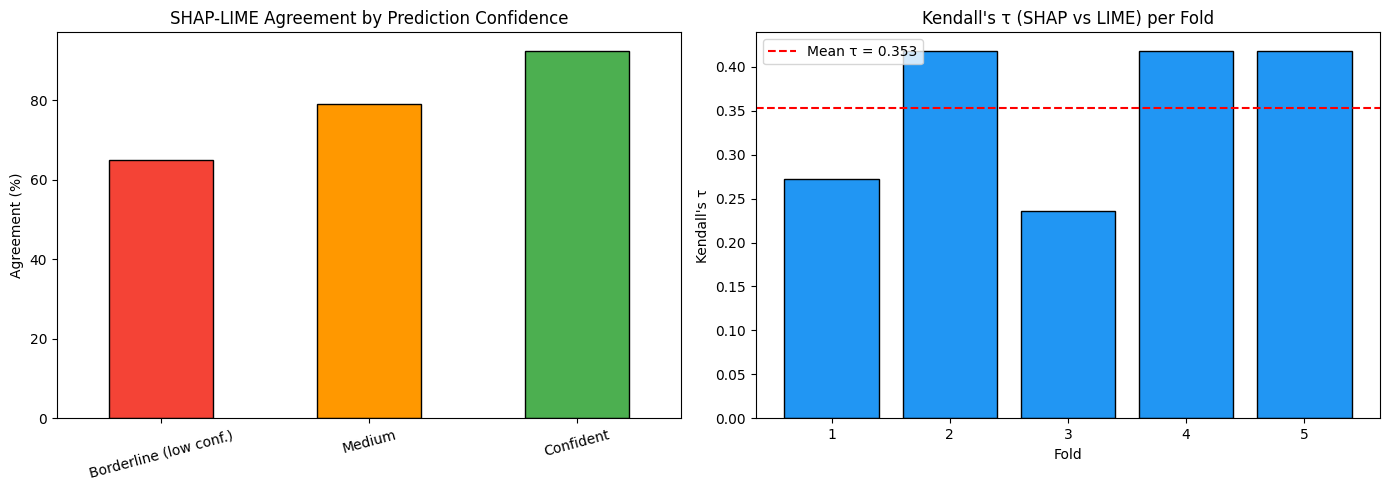


✅ Disagreement Analysis Complete!
📊 Correlation (Confidence vs Agreement): r = 0.3076, p-value = 0.0000
✅ Statistically significant — confirms confidence genuinely predicts SHAP-LIME agreement (not just noise from small bins).

📊 95% Clopper-Pearson CI for each confidence band:
   Borderline (low conf.)  : 76/117 = 64.96%  [95% CI: 55.59%, 73.55%]
   Medium                  : 121/153 = 79.08%  [95% CI: 71.78%, 85.23%]
   Confident               : 321/347 = 92.51%  [95% CI: 89.21%, 95.05%]

💡 Key Finding: Agreement is higher for confident predictions vs borderline cases.


In [ ]:
# ── DISAGREEMENT ANALYSIS ─────────────────────
disagree_df = pd.DataFrame(disagreement_records)

overall_agreement = disagree_df['Agree'].mean() * 100
print(f"📊 Overall Top-Feature Agreement (SHAP vs LIME): {overall_agreement:.2f}%")
print(f"   (Out of {len(disagree_df)} explained samples across 5 folds)")

# Distance from decision boundary (0.5 = most uncertain)
disagree_df['Distance_from_boundary'] = np.abs(disagree_df['Predicted_Prob'] - 0.5)
disagree_df['Confidence'] = pd.cut(
    disagree_df['Distance_from_boundary'],
    bins=[0, 0.15, 0.35, 0.5],
    labels=['Borderline (low conf.)', 'Medium', 'Confident']
)

agreement_by_confidence = disagree_df.groupby('Confidence', observed=True)['Agree'].agg(['mean','count'])
agreement_by_confidence['mean'] = agreement_by_confidence['mean'] * 100
agreement_by_confidence.columns = ['Agreement_%', 'N_samples']

print("\n📊 SHAP-LIME Agreement by Prediction Confidence:")
print(agreement_by_confidence.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

agreement_by_confidence['Agreement_%'].plot(
    kind='bar', ax=axes[0], color=['#F44336','#FF9800','#4CAF50'], edgecolor='black'
)
axes[0].set_title('SHAP-LIME Agreement by Prediction Confidence')
axes[0].set_ylabel('Agreement (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(tau_df['Fold'], tau_df['Kendall_tau'], color='#2196F3', edgecolor='black')
axes[1].axhline(y=tau_df['Kendall_tau'].mean(), color='red', linestyle='--',
                 label=f"Mean τ = {tau_df['Kendall_tau'].mean():.3f}")
axes[1].set_title("Kendall's τ (SHAP vs LIME) per Fold")
axes[1].set_xlabel('Fold')
axes[1].set_ylabel("Kendall's τ")
axes[1].legend()

plt.tight_layout()
plt.savefig('disagreement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Disagreement Analysis Complete!")

from scipy.stats import pointbiserialr

corr, corr_p = pointbiserialr(disagree_df['Distance_from_boundary'], disagree_df['Agree'].astype(int))
print(f"📊 Correlation (Confidence vs Agreement): r = {corr:.4f}, p-value = {corr_p:.4f}")
if corr_p < 0.05:
    print("✅ Statistically significant — confirms confidence genuinely predicts SHAP-LIME agreement (not just noise from small bins).")
else:
    print("⚠️ Not statistically significant at n=150 — the confidence-agreement pattern trend exists but isn't conclusively proven yet.")

from statsmodels.stats.proportion import proportion_confint

print("\n📊 95% Clopper-Pearson CI for each confidence band:")
ci_summary_rows = []
for level in ['Borderline (low conf.)', 'Medium', 'Confident']:
    band_data = disagree_df[disagree_df['Confidence'] == level]
    n_band = len(band_data)
    agree_band = int(band_data['Agree'].sum())
    rate_band = agree_band / n_band if n_band > 0 else float('nan')
    lo, hi = proportion_confint(agree_band, n_band, alpha=0.05, method='beta')
    ci_summary_rows.append({
        'Confidence Band': level, 'N': n_band,
        'Agreement (%)': round(rate_band*100, 2),
        '95% CI Low': round(lo*100, 2), '95% CI High': round(hi*100, 2)
    })
    print(f"   {level:24s}: {agree_band}/{n_band} = {rate_band*100:.2f}%  [95% CI: {lo*100:.2f}%, {hi*100:.2f}%]")

ci_summary_df = pd.DataFrame(ci_summary_rows)
higher_lower = 'higher' if agreement_by_confidence['Agreement_%'].iloc[-1] > agreement_by_confidence['Agreement_%'].iloc[0] else 'lower'
print(f"\n💡 Key Finding: Agreement is {higher_lower} for confident predictions vs borderline cases.")

## 7.3 Global SHAP Summary and Example LIME Explanation — Proposed Ensemble

⏳ Full-data hyperparameter tuning (for the illustrative/deployment model)...
✅ Full-data tuned XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
✅ Full-data tuned RF:      {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 30}


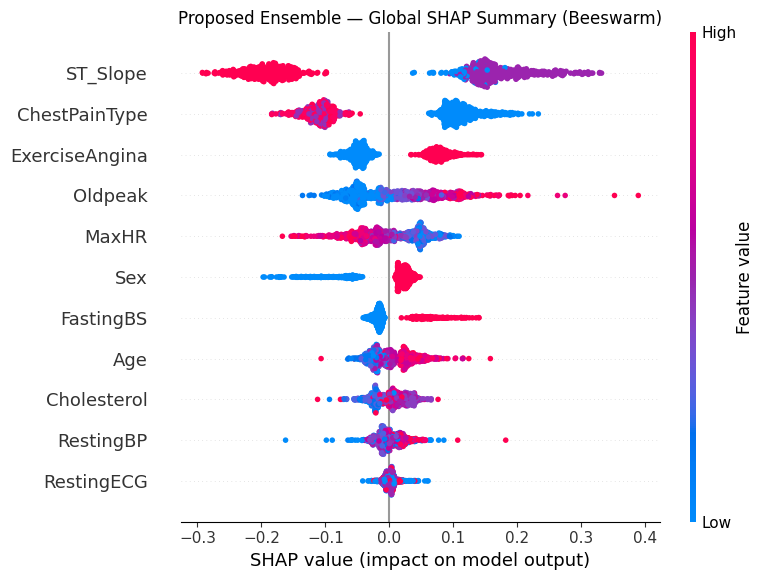

✅ Global SHAP summary plot saved as proposed_shap_summary.png


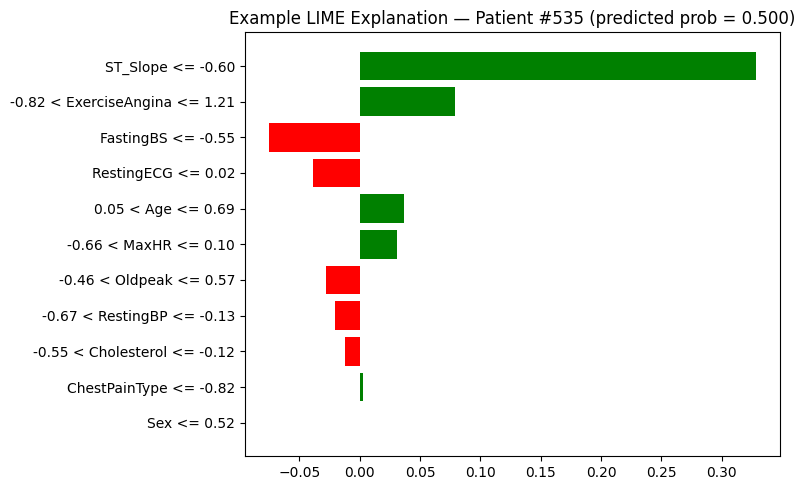


✅ Example LIME explanation saved as lime_example.png
   Patient #535: true label = 0, predicted prob = 0.500 (chosen as a near-borderline case)


In [ ]:
# ================================================
# Global SHAP Summary Plot + Single-Patient LIME Example
# (Proposed Work's own tuned model, trained on full data for illustration —
#  NOT used for any reported metric, purely for visualization)
# ================================================

# >>> ADDED: this full-data illustrative/deployment model gets its OWN tuning
# on the full dataset (best_rf_params / best_xgb_params now only hold the LAST
# outer fold's fold-specific params from the nested-CV loop above, which is not
# an appropriate choice for a full-data refit — a fresh full-data tuning run is
# both more principled and leakage-free here, since there is no held-out test
# set at this stage; Cleveland remains the true external test set, untouched).
print("⏳ Full-data hyperparameter tuning (for the illustrative/deployment model)...")

final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X)

xgb_search_full = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
)
xgb_search_full.fit(X_full_scaled, y)
best_xgb_params_full = xgb_search_full.best_params_

rf_search_full = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_search_full.fit(X_full_scaled, y)
best_rf_params_full = rf_search_full.best_params_

print(f"✅ Full-data tuned XGBoost: {best_xgb_params_full}")
print(f"✅ Full-data tuned RF:      {best_rf_params_full}")

sm_full = SMOTE(random_state=42)
X_full_sm, y_full_sm = sm_full.fit_resample(X_full_scaled, y)

rf_final = RandomForestClassifier(**best_rf_params_full, random_state=42)
rf_final.fit(X_full_sm, y_full_sm)

explainer_final = shap.TreeExplainer(rf_final)
shap_values_final = explainer_final.shap_values(X_full_scaled)
if isinstance(shap_values_final, list):
    sv_final = shap_values_final[1]
elif len(shap_values_final.shape) == 3:
    sv_final = shap_values_final[:, :, 1]
else:
    sv_final = shap_values_final

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_final, X_full_scaled, feature_names=feature_names, show=False)
plt.title("Proposed Ensemble — Global SHAP Summary (Beeswarm)")
plt.tight_layout()
plt.savefig('proposed_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Global SHAP summary plot saved as proposed_shap_summary.png")

# ── Example: single-patient LIME explanation (for methodology illustration) ──
lime_explainer_final = lime.lime_tabular.LimeTabularExplainer(
    X_full_sm,
    feature_names=feature_names,
    class_names=['No CVD', 'CVD'],
    mode='classification',
    random_state=42
)

# Pick one borderline-confidence example from the pooled predictions for illustration
example_idx = (perf_all['y_prob'] - 0.5).abs().idxmin()
example_row = X.iloc[example_idx].values
example_scaled = final_scaler.transform(example_row.reshape(1, -1))[0]

exp = lime_explainer_final.explain_instance(
    example_scaled, rf_final.predict_proba, num_features=len(feature_names)
)

fig = exp.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.title(f"Example LIME Explanation — Patient #{example_idx} (predicted prob = {perf_all.loc[example_idx, 'y_prob']:.3f})")
plt.tight_layout()
plt.savefig('lime_example.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Example LIME explanation saved as lime_example.png")
print(f"   Patient #{example_idx}: true label = {perf_all.loc[example_idx, 'y_true']}, "
      f"predicted prob = {perf_all.loc[example_idx, 'y_prob']:.3f} (chosen as a near-borderline case)")


#8 Calibration Analysis (Tuned Ensemble)

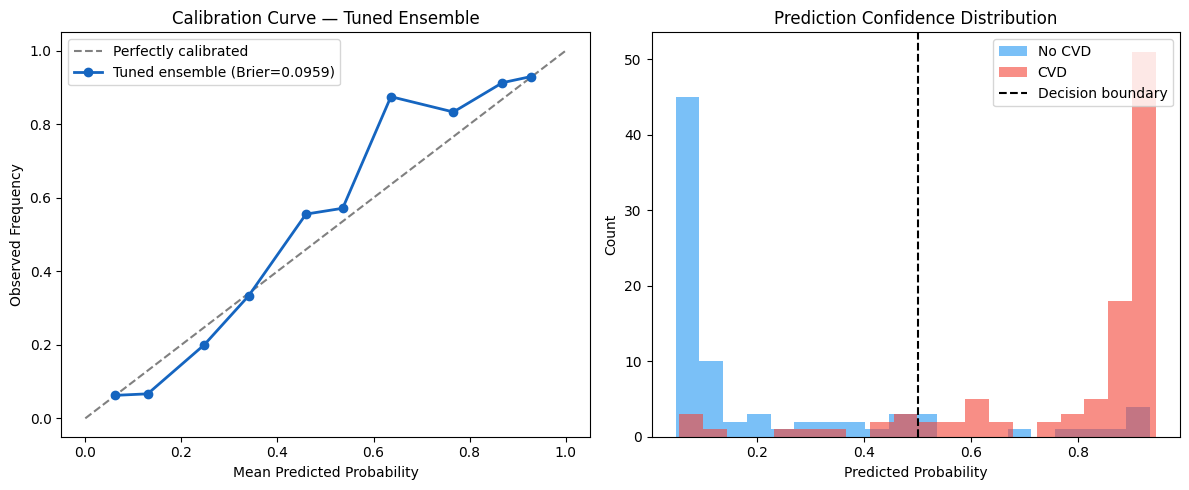

   CALIBRATION RESULTS — TUNED ENSEMBLE

Brier Score: 0.0959  (0.0=perfect | 0.25=random)
✅ Well-calibrated — this justifies using confidence as
   a predictor of SHAP-LIME agreement.


In [ ]:
# ================================================
# 8 Calibration Analysis (Tuned Ensemble)
# ================================================
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split

# Train-test split (fresh, only for this diagnostic check)
X_train0, X_test0, y_train0, y_test0 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler0 = StandardScaler()
X_train0_s = scaler0.fit_transform(X_train0)
X_test0_s = scaler0.transform(X_test0)

# SMOTE only on training split
sm0 = SMOTE(random_state=42)
X_train0_sm, y_train0_sm = sm0.fit_resample(X_train0_s, y_train0)

# Tuned ensemble using the SAME best params as main analysis (best_rf_params, best_xgb_params)
tuned_ensemble_cal = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(**best_rf_params, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)
tuned_ensemble_cal.fit(X_train0_sm, y_train0_sm)

# Explicit calibration (sigmoid, 5-fold) on the tuned ensemble
calibrated_model = CalibratedClassifierCV(
    estimator=tuned_ensemble_cal,
    method='sigmoid',
    cv=5,
    ensemble='auto'
)
calibrated_model.fit(X_train0_sm, y_train0_sm)

y_prob0 = calibrated_model.predict_proba(X_test0_s)[:, 1]
brier = brier_score_loss(y_test0, y_prob0)
prob_true, prob_pred = calibration_curve(y_test0, y_prob0, n_bins=10)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
ax[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='#1565C0',
           label=f'Tuned ensemble (Brier={brier:.4f})')
ax[0].set_xlabel('Mean Predicted Probability')
ax[0].set_ylabel('Observed Frequency')
ax[0].set_title('Calibration Curve — Tuned Ensemble')
ax[0].legend()

ax[1].hist(y_prob0[y_test0 == 0], bins=20, alpha=0.6, color='#2196F3', label='No CVD')
ax[1].hist(y_prob0[y_test0 == 1], bins=20, alpha=0.6, color='#F44336', label='CVD')
ax[1].axvline(0.5, color='black', linestyle='--', label='Decision boundary')
ax[1].set_xlabel('Predicted Probability')
ax[1].set_ylabel('Count')
ax[1].set_title('Prediction Confidence Distribution')
ax[1].legend()

plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("   CALIBRATION RESULTS — TUNED ENSEMBLE")
print("=" * 50)
print(f"\nBrier Score: {brier:.4f}  (0.0=perfect | 0.25=random)")
if brier < 0.15:
    print("✅ Well-calibrated — this justifies using confidence as")
    print("   a predictor of SHAP-LIME agreement.")
else:
    print("⚠️ Moderately calibrated — acceptable.")

## 9. Final Comparison — Base Paper A vs Base Paper B vs Proposed Work

           FINAL COMPARISON — ALL THREE APPROACHES
                                  Method Accuracy (%)        F1-Score         ROC-AUC                 XAI Method              SHAP-LIME Agreement
            Base Paper A (Ensemble+SHAP)        86.96          0.8812          0.9277                  SHAP only                              N/A
       Base Paper B (Ensemble+SHAP+LIME)         87.5          0.8856          0.9206 SHAP + LIME (single split)       τ = -0.4909 (single split)
Proposed Work (SMOTE+Ensemble+Agreement) 86.71 ± 2.78 0.8805 ± 0.0245 0.9279 ± 0.0216    SHAP + LIME (5-fold CV) τ = 0.3527 ± 0.0905 (5-fold avg)


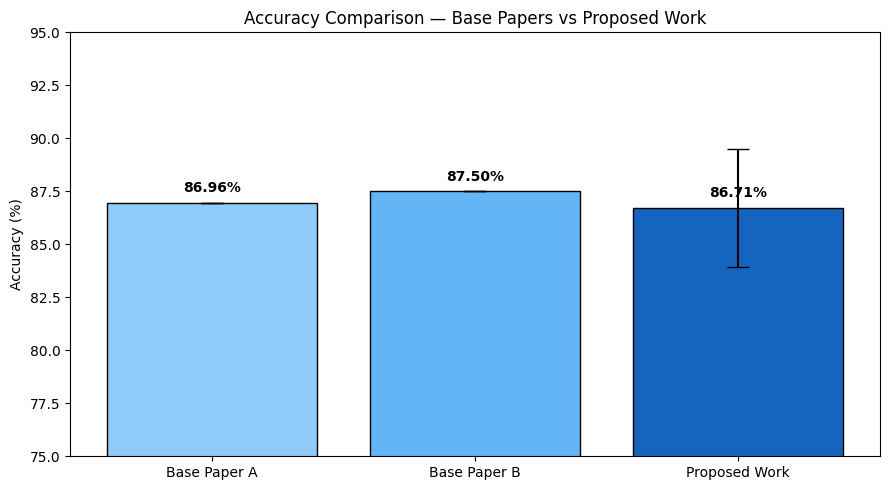


📌 SUMMARY FOR PRESENTATION:

1. Base Paper A (Ensemble+SHAP) replicated → 86.96% accuracy
2. Base Paper B (Ensemble+SHAP+LIME) replicated → 87.5% accuracy
3. Proposed Work: Leakage-free SMOTE + 5-Fold CV Ensemble → 86.71% ± 2.78% accuracy

KEY NOVELTY FINDINGS:
- SHAP-LIME overall agreement: 83.95%
- Agreement on CONFIDENT predictions: 92.51%
- Agreement on BORDERLINE predictions: 64.96%
- This gap (27.55 percentage points) is the key novel contribution:
  explanation reliability drops sharply for uncertain/borderline predictions.



In [ ]:
# ── FINAL COMPARISON TABLE ────────────────────

comparison = pd.DataFrame({
    'Method': ['Base Paper A (Ensemble+SHAP)', 'Base Paper B (Ensemble+SHAP+LIME)', 'Proposed Work (SMOTE+Ensemble+Agreement)'],
    'Accuracy (%)': [
        results_A['Voting']['Accuracy'],
        results_B['Accuracy'],
        f"{results_df['Accuracy'].mean():.2f} ± {results_df['Accuracy'].std():.2f}"
    ],
    'F1-Score': [
        results_A['Voting']['F1-Score'],
        results_B['F1-Score'],
        f"{results_df['F1'].mean():.4f} ± {results_df['F1'].std():.4f}"
    ],
    'ROC-AUC': [
        results_A['Voting']['ROC-AUC'],
        results_B['ROC-AUC'],
        f"{results_df['AUC'].mean():.4f} ± {results_df['AUC'].std():.4f}"
    ],
    'XAI Method': ['SHAP only', 'SHAP + LIME (single split)', 'SHAP + LIME (5-fold CV)'],
    'SHAP-LIME Agreement': ['N/A', f"τ = {tau:.4f} (single split)", f"τ = {tau_df['Kendall_tau'].mean():.4f} ± {tau_df['Kendall_tau'].std():.4f} (5-fold avg)"]
})

print("="*80)
print("           FINAL COMPARISON — ALL THREE APPROACHES")
print("="*80)
print(comparison.to_string(index=False))

# ── VISUAL COMPARISON CHART ───────────────────
fig, ax = plt.subplots(figsize=(9, 5))

methods = ['Base Paper A', 'Base Paper B', 'Proposed Work']
accuracies = [
    results_A['Voting']['Accuracy'],
    results_B['Accuracy'],
    results_df['Accuracy'].mean()
]
errors = [0, 0, results_df['Accuracy'].std()]

bars = ax.bar(methods, accuracies, yerr=errors, capsize=8,
               color=['#90CAF9','#64B5F6','#1565C0'], edgecolor='black')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Comparison — Base Papers vs Proposed Work')
ax.set_ylim(75, 95)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("📌 SUMMARY FOR PRESENTATION:")
print("="*80)
print(f"""
1. Base Paper A (Ensemble+SHAP) replicated → {results_A['Voting']['Accuracy']}% accuracy
2. Base Paper B (Ensemble+SHAP+LIME) replicated → {results_B['Accuracy']}% accuracy
3. Proposed Work: Leakage-free SMOTE + 5-Fold CV Ensemble → {results_df['Accuracy'].mean():.2f}% ± {results_df['Accuracy'].std():.2f}% accuracy

KEY NOVELTY FINDINGS:
- SHAP-LIME overall agreement: {overall_agreement:.2f}%
- Agreement on CONFIDENT predictions: {agreement_by_confidence['Agreement_%'].iloc[-1]:.2f}%
- Agreement on BORDERLINE predictions: {agreement_by_confidence['Agreement_%'].iloc[0]:.2f}%
- This gap ({agreement_by_confidence['Agreement_%'].iloc[-1] - agreement_by_confidence['Agreement_%'].iloc[0]:.2f} percentage points) is the key novel contribution:
  explanation reliability drops sharply for uncertain/borderline predictions.
""")

## 10. External Validation — Cleveland Dataset (Independent Cohort)

The final ensemble is refit on the **entire fedesoriano dataset** (all 918 patients, SMOTE-balanced) — no fedesoriano data is held back, since the true held-out test set here is the **Cleveland dataset (n=297)**, which was never seen during training, tuning, or SMOTE resampling.

**Before running this cell:** upload `cleveland_external_mapped.csv` to the Colab session (same way `heart.csv` was uploaded). This file already has Cleveland's raw UCI columns mapped onto the fedesoriano schema (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`, `HeartDisease`, etc.), with `ca` and `thal` dropped since fedesoriano has no equivalent.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleveland_external_mapped.csv to cleveland_external_mapped.csv


In [ ]:
# ================================================
# 10. External Validation — Cleveland Dataset (n=297, independent cohort)
# ================================================
from sklearn.metrics import confusion_matrix

print("⏳ Training final ensemble on FULL fedesoriano dataset (for external validation)...")

# Reuses X_full_sm / y_full_sm, final_scaler, and the full-data-tuned
# best_rf_params_full / best_xgb_params_full already built in Section 7.3
# (full fedesoriano dataset, SMOTE-balanced, scaler + tuning fit only on
# fedesoriano — never on Cleveland)
final_ensemble_full = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(**best_rf_params_full, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(**best_xgb_params_full, random_state=42, eval_metric='logloss')),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)
final_ensemble_full.fit(X_full_sm, y_full_sm)
print("✅ Final ensemble trained on all 918 fedesoriano patients (SMOTE-balanced).")

# ── Load external Cleveland dataset (already column-mapped to fedesoriano schema) ──
ext_df = pd.read_csv('cleveland_external_mapped.csv')
print(f"\n📂 Loaded external dataset: {ext_df.shape[0]} patients, {ext_df.shape[1]-1} features")

# ── Apply the SAME categorical encoding used on fedesoriano ──
# (sklearn's LabelEncoder assigns codes by alphabetical order of the category strings;
#  since Cleveland was mapped onto fedesoriano's exact category labels, this reproduces
#  the identical encoding fedesoriano received in Section 4, without needing the original
#  per-column LabelEncoder objects, which weren't retained separately.)
cat_mappings = {
    'Sex':            {'F': 0, 'M': 1},
    'ChestPainType':  {'ASY': 0, 'ATA': 1, 'NAP': 2, 'TA': 3},
    'RestingECG':     {'LVH': 0, 'Normal': 1, 'ST': 2},
    'ExerciseAngina': {'N': 0, 'Y': 1},
    'ST_Slope':       {'Down': 0, 'Flat': 1, 'Up': 2},
}
for col, mapping in cat_mappings.items():
    ext_df[col] = ext_df[col].map(mapping)

X_ext = ext_df[feature_names]     # enforce identical column order as training
y_ext = ext_df['HeartDisease']

assert X_ext.isna().sum().sum() == 0, "Unmapped category found — check cat_mappings against ext_df's unique values."

# ── Scale with the scaler fit on fedesoriano only (never re-fit on external data) ──
X_ext_scaled = final_scaler.transform(X_ext)

# ── Predict & evaluate ──
y_ext_pred = final_ensemble_full.predict(X_ext_scaled)
y_ext_prob = final_ensemble_full.predict_proba(X_ext_scaled)[:, 1]

ext_acc  = accuracy_score(y_ext, y_ext_pred)
ext_prec = precision_score(y_ext, y_ext_pred)
ext_rec  = recall_score(y_ext, y_ext_pred)
ext_f1   = f1_score(y_ext, y_ext_pred)
ext_auc  = roc_auc_score(y_ext, y_ext_prob)
tn, fp, fn, tp = confusion_matrix(y_ext, y_ext_pred).ravel()
specificity = tn / (tn + fp)

print("\n" + "="*50)
print("   EXTERNAL VALIDATION — CLEVELAND DATASET (n=297)")
print("="*50)
print(f"\nAccuracy:             {ext_acc*100:.2f}%")
print(f"Precision:            {ext_prec*100:.2f}%")
print(f"Recall (Sensitivity): {ext_rec*100:.2f}%")
print(f"Specificity:          {specificity*100:.2f}%")
print(f"F1-Score:             {ext_f1:.4f}")
print(f"ROC-AUC:              {ext_auc:.4f}")
print(f"\nConfusion Matrix — TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

print(f"\n📌 For comparison — fedesoriano 5-fold CV performance (Section 7):")
print(f"   Accuracy: {results_df['Accuracy'].mean():.2f}% ± {results_df['Accuracy'].std():.2f}")
print(f"   ROC-AUC : {results_df['AUC'].mean():.4f} ± {results_df['AUC'].std():.4f}")


⏳ Training final ensemble on FULL fedesoriano dataset (for external validation)...
✅ Final ensemble trained on all 918 fedesoriano patients (SMOTE-balanced).

📂 Loaded external dataset: 297 patients, 11 features

   EXTERNAL VALIDATION — CLEVELAND DATASET (n=297)

Accuracy:             85.52%
Precision:            87.90%
Recall (Sensitivity): 79.56%
Specificity:          90.62%
F1-Score:             0.8352
ROC-AUC:              0.9429

Confusion Matrix — TN: 145, FP: 15, FN: 28, TP: 109

📌 For comparison — fedesoriano 5-fold CV performance (Section 7):
   Accuracy: 86.71% ± 2.78
   ROC-AUC : 0.9279 ± 0.0216
